<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn


# Regression Workshop

Regression is a supervised learning task where we predict a **continuous numeric value**.

In this notebook, we will:
1. Load a regression dataset.
2. Run quick EDA.
3. Preprocess and split the data.
4. Train and evaluate:
   - Polynomial Regression
   - Support Vector Regression (SVR)
   - Gradient Boosting Regressor
5. Compare model performance.


In [1]:
# Imports and setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(42)


In [2]:
# Load dataset (California Housing)
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

print('Shape:', df.shape)
print('Target column:', data.target_names[0])


Shape: (20640, 9)
Target column: MedHouseVal


## Quick Dataset Introduction

The California Housing dataset contains district-level features such as median income,
house age, average rooms, population, and geographic location.

- **Target**: median house value (`MedHouseVal`) in units of 100,000 USD.
- All columns are numeric, which makes it convenient for a first regression workshop.


In [3]:
# Basic EDA
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print('Null values per column:')
print(df.isnull().sum())

print('\nDuplicated rows:', df.duplicated().sum())

print('\nStatistical summary:')
print(df.describe().T)


Null values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicated rows: 0

Statistical summary:
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%   

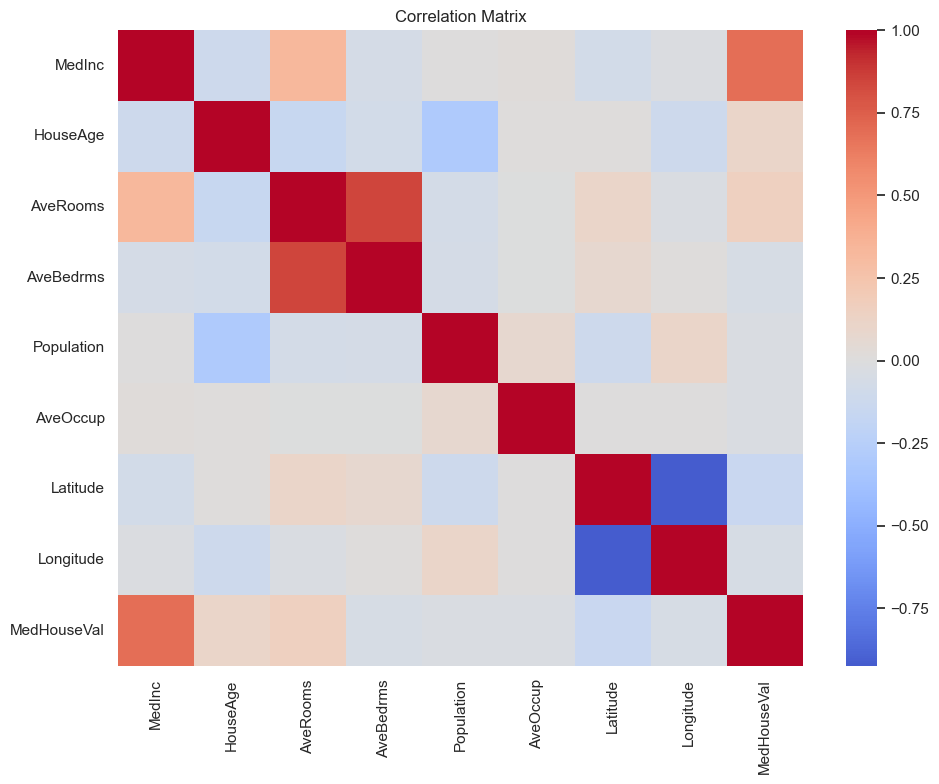

In [5]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


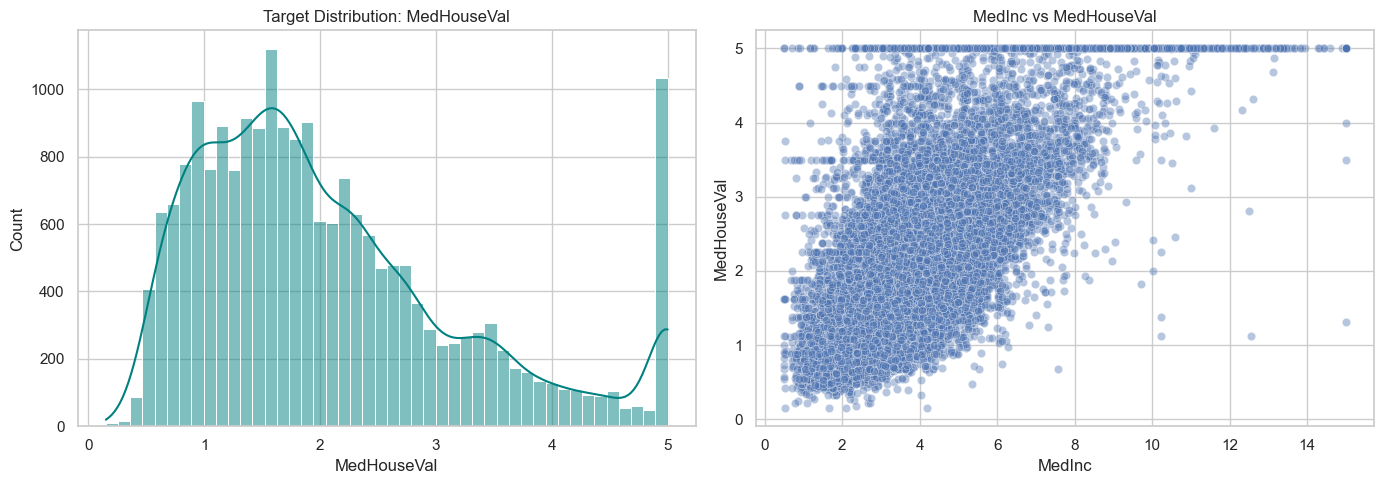

In [6]:
# A few quick visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['MedHouseVal'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Target Distribution: MedHouseVal')

sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.4, ax=axes[1])
axes[1].set_title('MedInc vs MedHouseVal')

plt.tight_layout()
plt.show()


## Preprocessing

We will:
- Split into train/test.
- Use median imputation for robustness.
- Apply scaling where needed.

Polynomial and SVR are sensitive to feature scaling, so we use pipelines.
Gradient Boosting is tree-based and less sensitive to scaling.


In [7]:
# Split
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (16512, 8)
Test shape: (4128, 8)


In [8]:
# Common evaluation helper
results = []

def evaluate_regressor(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    metrics = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }
    results.append(metrics)
    return pd.Series(metrics)


## Polynomial Regression

Polynomial Regression expands features into polynomial terms,
then fits a linear regression model on top of those transformed features.
It can model non-linear relationships while staying in the linear-model family.


In [9]:
poly_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression()),
])

print('Polynomial Regression metrics:')
print(evaluate_regressor('Polynomial (deg=2)', poly_model, X_train, X_test))


Polynomial Regression metrics:
Model    Polynomial (deg=2)
MAE                0.467001
RMSE               0.681397
R2                 0.645682
dtype: object


## Support Vector Regression (SVR)

SVR tries to fit a function within an error margin (epsilon tube) while maximizing margin.
With an RBF kernel, it can capture strong non-linear patterns.


In [10]:
svr_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=20, epsilon=0.1, gamma='scale')),
])

print('SVR metrics:')
print(evaluate_regressor('SVR (RBF)', svr_model, X_train, X_test))


SVR metrics:
Model    SVR (RBF)
MAE       0.373659
RMSE      0.564185
R2        0.757095
dtype: object


## Gradient Boosting Regressor

Gradient Boosting builds trees sequentially, where each new tree
focuses on the previous model's errors. It is usually a strong baseline for tabular data.


In [11]:
gbr_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('gbr', GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    )),
])

print('Gradient Boosting metrics:')
print(evaluate_regressor('Gradient Boosting', gbr_model, X_train, X_test))


Gradient Boosting metrics:
Model    Gradient Boosting
MAE               0.345527
RMSE               0.50963
R2                0.801801
dtype: object


## Final Comparison

For MAE and RMSE, lower is better. For R2, higher is better.


In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,0.345527,0.509630,0.801801
1,SVR (RBF),0.373659,0.564185,0.757095
2,Polynomial (deg=2),0.467001,0.681397,0.645682


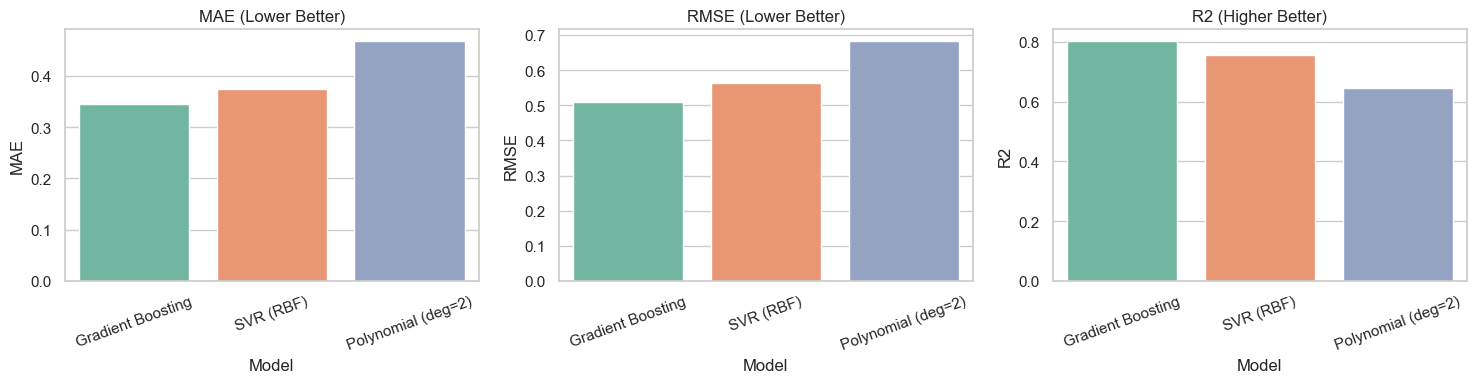

In [13]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[0], palette='Set2')
axes[0].set_title('MAE (Lower Better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1], palette='Set2')
axes[1].set_title('RMSE (Lower Better)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2', ax=axes[2], palette='Set2')
axes[2].set_title('R2 (Higher Better)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### Wrap-Up

This notebook gives you three different regression families:
- Feature expansion + linear model (Polynomial Regression)
- Margin-based kernel method (SVR)
- Tree ensemble boosting (Gradient Boosting)

From here, you can tune hyperparameters and use cross-validation for a stronger comparison.
